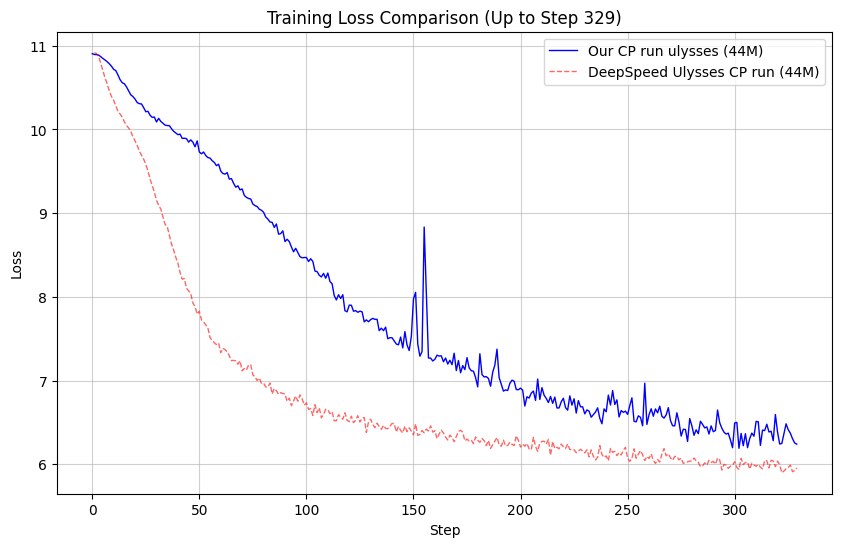

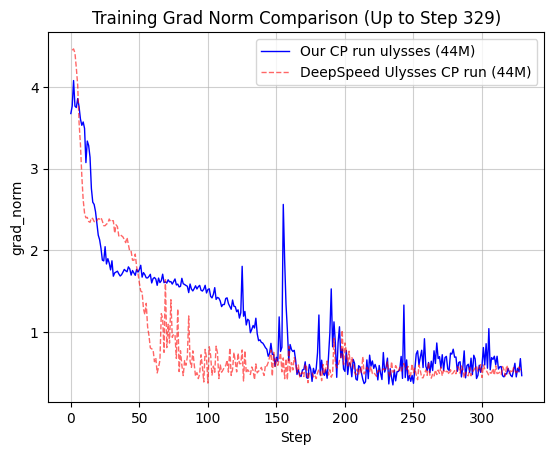

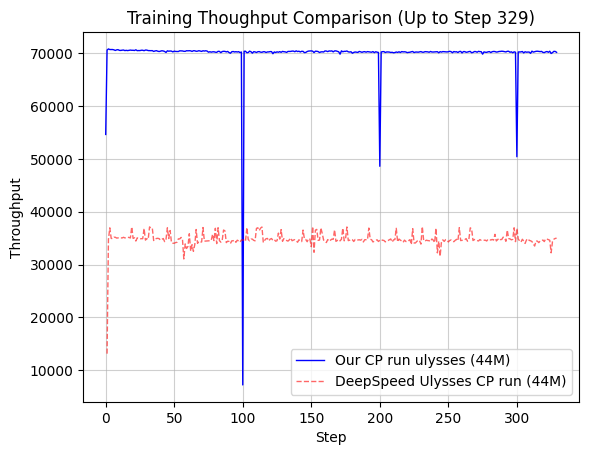

Max. Throughput Our CP run ulysses (44M): 70790.118277
Avg. Throughput Our CP run ulysses (44M): 69915.82022112425
Min Train Loss Our CP run ulysses (44M): 6.191337
Min Val Loss Our CP run ulysses (44M): 6.49829
Avg. Time Our CP run ulysses (44M): 960.3783450939393
Avg. Data Time Our CP run ulysses (44M): 0.5972528484848485
Avg. Forward Time Our CP run ulysses (44M): 293.09941057272727
Avg. Loss Time Our CP run ulysses (44M): 20.469704436363635
Avg. Backward Time Our CP run ulysses (44M): 565.154692269697

Max. Throughput DeepSpeed Ulysses CP run (44M): 37169.7
Avg. Throughput DeepSpeed Ulysses CP run (44M): 34743.98996960486
Min Train Loss DeepSpeed Ulysses CP run (44M): 5.89941
Min Val Loss DeepSpeed Ulysses CP run (44M): nan
Avg. Time DeepSpeed Ulysses CP run (44M): 1893.3773130699087
Avg. Data Time DeepSpeed Ulysses CP run (44M): 27.81383282674772
Avg. Forward Time DeepSpeed Ulysses CP run (44M): 493.41889969604864
Avg. Loss Time DeepSpeed Ulysses CP run (44M): 0.0
Avg. Backward Ti

In [11]:

import pandas as pd
import matplotlib.pyplot as plt

# plt.style.use('')

# Load datasets
df_new = pd.read_csv('/home/blu-bridge25/CP/CP_GPT2_Training_logs/CP_Training_log1.csv')
df_old = pd.read_csv('/home/blu-bridge25/LlamaFactory/outputs/gpt2_44m_pt_fsdp2_ulysses/training_log.csv')
# df_3rd = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/CP_Training_logs/CP_Training_log162.csv')

if not df_new.empty:
    df_old.columns = df_old.columns.str.strip()
    df_new.columns = df_new.columns.str.strip()
    # df_3rd.columns = df_3rd.columns.str.strip()

# 1. Get the current progress (max step of the new run)
current_max_step = df_new['step'].max()

# 2 Filter the old run to match the current progress
df_old_truncated = df_old[df_old['step'] <= current_max_step]
# # # df_3rd_truncated = df_3rd[df_3rd['step'] <= current_max_step]

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['loss'], label='Our CP run ulysses (44M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['loss'], label='DeepSpeed Ulysses CP run (44M)',linewidth = 1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['loss'], label='Our CP run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title(f'Training Loss Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='Our CP run ulysses (44M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['grad_norm'], label='DeepSpeed Ulysses CP run (44M)',linewidth = 1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['grad_norm'], label='Our CP run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='Our CP run ulysses (44M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['tok_per_sec'], label='DeepSpeed Ulysses CP run (44M)',linewidth=1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['tok_per_sec'], label='Our CP run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.8)

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput Our CP run ulysses (44M):",df_new['tok_per_sec'].max())
print("Avg. Throughput Our CP run ulysses (44M):",df_new['tok_per_sec'].mean())
print("Min Train Loss Our CP run ulysses (44M):",df_new['loss'][:].min())
print("Min Val Loss Our CP run ulysses (44M):",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time Our CP run ulysses (44M):",df_new['dt_ms'].mean())
print("Avg. Data Time Our CP run ulysses (44M):",df_new['timer_data'][:].mean())
print("Avg. Forward Time Our CP run ulysses (44M):",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time Our CP run ulysses (44M):",df_new['timer_loss'][:].mean())
print("Avg. Backward Time Our CP run ulysses (44M):",df_new['timer_bwd'][:].mean())


print("\nMax. Throughput DeepSpeed Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].max())
print("Avg. Throughput DeepSpeed Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].mean())
print("Min Train Loss DeepSpeed Ulysses CP run (44M):",df_old_truncated['loss'][:].min())
print("Min Val Loss DeepSpeed Ulysses CP run (44M):",df_old_truncated['val_loss'].where(df_old_truncated['val_loss']!=(-1)).min())
print("Avg. Time DeepSpeed Ulysses CP run (44M):",df_old_truncated['dt_ms'].mean())
print("Avg. Data Time DeepSpeed Ulysses CP run (44M):",df_old_truncated['timer_data'][:].mean())
print("Avg. Forward Time DeepSpeed Ulysses CP run (44M):",df_old_truncated['timer_fwd'][:].mean())
print("Avg. Loss Time DeepSpeed Ulysses CP run (44M):",df_old_truncated['timer_loss'][:].mean())
print("Avg. Backward Time DeepSpeed Ulysses CP run (44M):",df_old_truncated['timer_bwd'][:].mean())




# print("\nMax. Throughput Our CP run before (44M):",df_3rd_truncated['tok_per_sec'].max())
# print("Avg. Throughput Our CP run before (44M):",df_3rd_truncated['tok_per_sec'].mean())
# print("Min Train Loss Our CP run before (44M):",df_3rd_truncated['loss'][:].min())
# # print("Min Val Loss Our CP run before (44M):",df_3rd_truncated['val_loss'].where(df_3rd_truncated['val_loss']!=(-1)).min())
# print("Avg. Time Our CP run before (44M):",df_3rd_truncated['dt_ms'].mean())
# print("Avg. Data Time Our CP run before (44M):",df_3rd_truncated['timer_data'][:].mean())
# print("Avg. Forward Time Our CP run before (44M):",df_3rd_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time Our CP run before (44M):",df_3rd_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time Our CP run before (44M):",df_3rd_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time Our CP run before (44M):",df_3rd_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time Our CP run before (44M):",df_3rd_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time Our CP run before (44M):",df_3rd_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time Our CP run before (44M):",df_3rd_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time Our CP run before (44M):",df_3rd_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time Our CP run before (44M):",df_3rd_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time Our CP run before (44M):",df_3rd_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time Our CP run before (44M):",df_3rd_truncated['timer_lm_head'][:].mean())

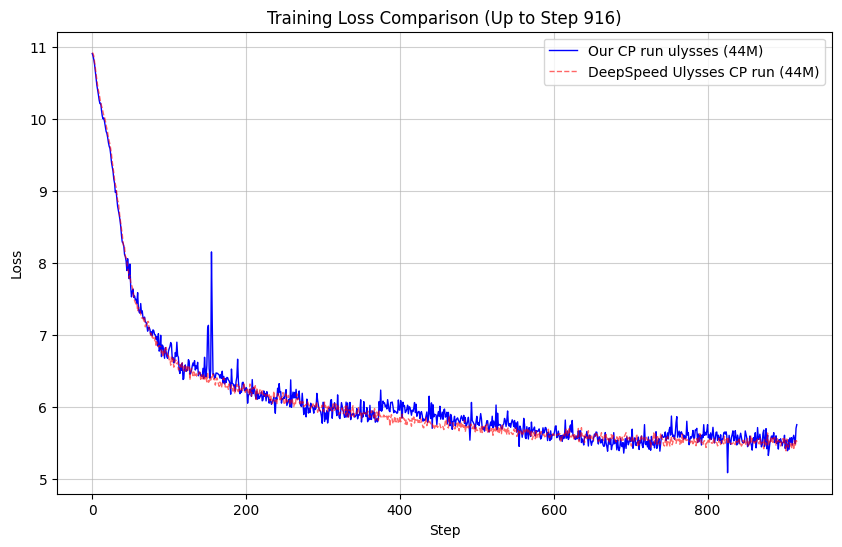

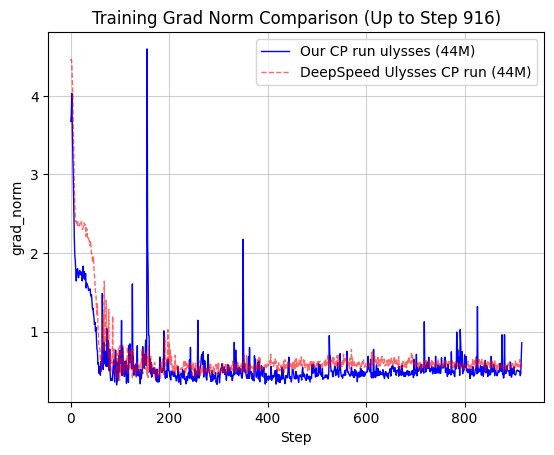

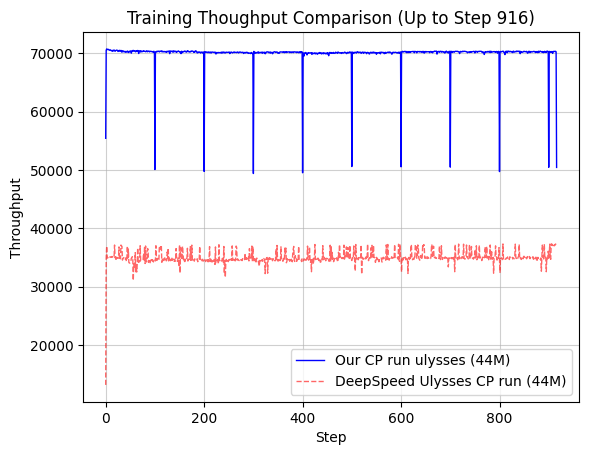

Max. Throughput Our CP run ulysses (44M): 70747.626683
Avg. Throughput Our CP run ulysses (44M): 69970.32577068158
Min Train Loss Our CP run ulysses (44M): 5.091862
Min Val Loss Our CP run ulysses (44M): 5.519863
Avg. Time Our CP run ulysses (44M): 937.8485429607416
Avg. Data Time Our CP run ulysses (44M): 0.5348972388222465
Avg. Forward Time Our CP run ulysses (44M): 293.4758858745911
Avg. Loss Time Our CP run ulysses (44M): 20.12829944601963
Avg. Backward Time Our CP run ulysses (44M): 566.6076425441657

Max. Throughput DeepSpeed Ulysses CP run (44M): 37349.2
Avg. Throughput DeepSpeed Ulysses CP run (44M): 34960.044056706654
Min Train Loss DeepSpeed Ulysses CP run (44M): 5.394938
Min Val Loss DeepSpeed Ulysses CP run (44M): nan
Avg. Time DeepSpeed Ulysses CP run (44M): 1877.927344601963
Avg. Data Time DeepSpeed Ulysses CP run (44M): 26.67646455834242
Avg. Forward Time DeepSpeed Ulysses CP run (44M): 491.61340567066514
Avg. Loss Time DeepSpeed Ulysses CP run (44M): 0.0
Avg. Backward T

In [141]:

import pandas as pd
import matplotlib.pyplot as plt

# plt.style.use('')

# Load datasets
df_new = pd.read_csv('/home/blu-bridge25/CP/CP_GPT2_Training_logs/CP_Training_log2.csv')
df_old = pd.read_csv('/home/blu-bridge25/LlamaFactory/outputs/gpt2_44m_pt_fsdp2_ulysses/training_log.csv')
# df_3rd = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/CP_Training_logs/CP_Training_log162.csv')

if not df_new.empty:
    df_old.columns = df_old.columns.str.strip()
    df_new.columns = df_new.columns.str.strip()
    # df_3rd.columns = df_3rd.columns.str.strip()

# LlamaFactory logs steps 1-indexed (v1 increments global_step before logging);
# the CP framework logs 0-indexed. Shift df_old to 0-indexed so both align.
df_old['step'] = df_old['step'] - 1


# 1. Get the current progress (max step of the new run)
current_max_step = df_new['step'].max()

# 2 Filter the old run to match the current progress
df_old_truncated = df_old[df_old['step'] <= current_max_step]
# # # df_3rd_truncated = df_3rd[df_3rd['step'] <= current_max_step]

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['loss'], label='Our CP run ulysses (44M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['loss'], label='DeepSpeed Ulysses CP run (44M)',linewidth = 1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['loss'], label='Our CP run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title(f'Training Loss Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='Our CP run ulysses (44M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['grad_norm'], label='DeepSpeed Ulysses CP run (44M)',linewidth = 1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['grad_norm'], label='Our CP run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='Our CP run ulysses (44M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['tok_per_sec'], label='DeepSpeed Ulysses CP run (44M)',linewidth=1, linestyle = "--", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['tok_per_sec'], label='Our CP run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.8)

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput Our CP run ulysses (44M):",df_new['tok_per_sec'].max())
print("Avg. Throughput Our CP run ulysses (44M):",df_new['tok_per_sec'].mean())
print("Min Train Loss Our CP run ulysses (44M):",df_new['loss'][:].min())
print("Min Val Loss Our CP run ulysses (44M):",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time Our CP run ulysses (44M):",df_new['dt_ms'].mean())
print("Avg. Data Time Our CP run ulysses (44M):",df_new['timer_data'][:].mean())
print("Avg. Forward Time Our CP run ulysses (44M):",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time Our CP run ulysses (44M):",df_new['timer_loss'][:].mean())
print("Avg. Backward Time Our CP run ulysses (44M):",df_new['timer_bwd'][:].mean())


print("\nMax. Throughput DeepSpeed Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].max())
print("Avg. Throughput DeepSpeed Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].mean())
print("Min Train Loss DeepSpeed Ulysses CP run (44M):",df_old_truncated['loss'][:].min())
print("Min Val Loss DeepSpeed Ulysses CP run (44M):",df_old_truncated['val_loss'].where(df_old_truncated['val_loss']!=(-1)).min())
print("Avg. Time DeepSpeed Ulysses CP run (44M):",df_old_truncated['dt_ms'].mean())
print("Avg. Data Time DeepSpeed Ulysses CP run (44M):",df_old_truncated['timer_data'][:].mean())
print("Avg. Forward Time DeepSpeed Ulysses CP run (44M):",df_old_truncated['timer_fwd'][:].mean())
print("Avg. Loss Time DeepSpeed Ulysses CP run (44M):",df_old_truncated['timer_loss'][:].mean())
print("Avg. Backward Time DeepSpeed Ulysses CP run (44M):",df_old_truncated['timer_bwd'][:].mean())




# print("\nMax. Throughput Our CP run before (44M):",df_3rd_truncated['tok_per_sec'].max())
# print("Avg. Throughput Our CP run before (44M):",df_3rd_truncated['tok_per_sec'].mean())
# print("Min Train Loss Our CP run before (44M):",df_3rd_truncated['loss'][:].min())
# # print("Min Val Loss Our CP run before (44M):",df_3rd_truncated['val_loss'].where(df_3rd_truncated['val_loss']!=(-1)).min())
# print("Avg. Time Our CP run before (44M):",df_3rd_truncated['dt_ms'].mean())
# print("Avg. Data Time Our CP run before (44M):",df_3rd_truncated['timer_data'][:].mean())
# print("Avg. Forward Time Our CP run before (44M):",df_3rd_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time Our CP run before (44M):",df_3rd_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time Our CP run before (44M):",df_3rd_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time Our CP run before (44M):",df_3rd_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time Our CP run before (44M):",df_3rd_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time Our CP run before (44M):",df_3rd_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time Our CP run before (44M):",df_3rd_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time Our CP run before (44M):",df_3rd_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time Our CP run before (44M):",df_3rd_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time Our CP run before (44M):",df_3rd_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time Our CP run before (44M):",df_3rd_truncated['timer_lm_head'][:].mean())

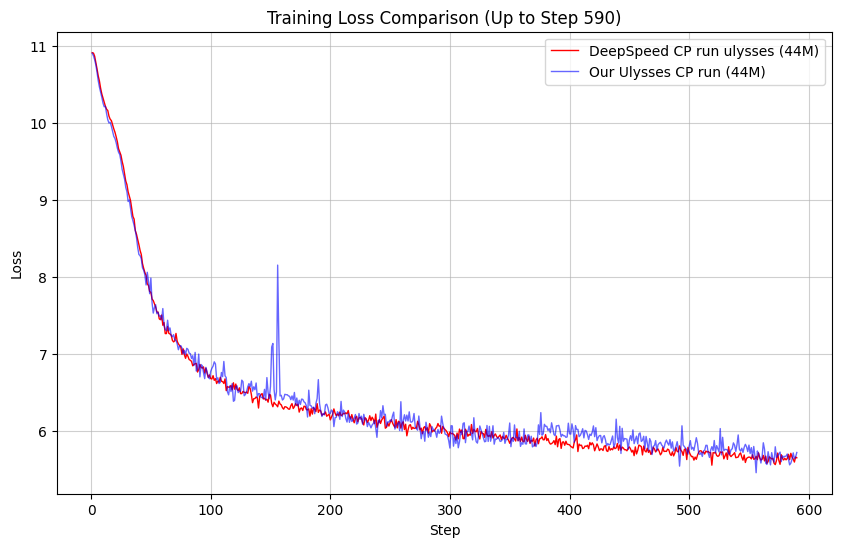

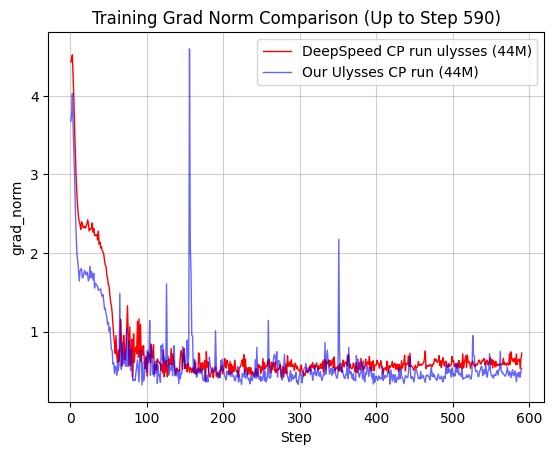

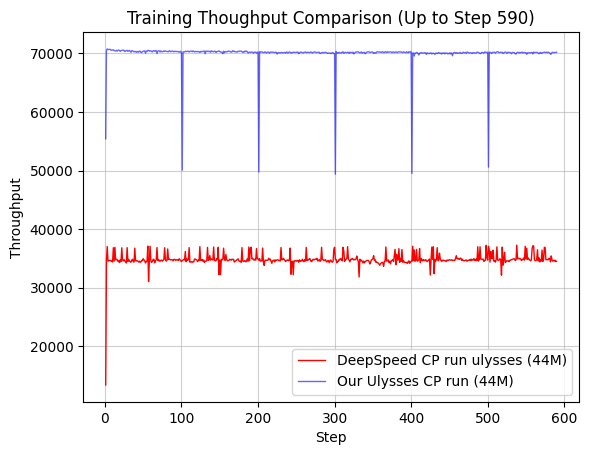

Max. Throughput DeepSpeed CP run ulysses (44M): 37276.6
Avg. Throughput DeepSpeed CP run ulysses (44M): 34828.91559322034
Min Train Loss DeepSpeed CP run ulysses (44M): 5.555071
Min Val Loss DeepSpeed CP run ulysses (44M): nan
Avg. Time DeepSpeed CP run ulysses (44M): 1885.7234983050848
Avg. Data Time DeepSpeed CP run ulysses (44M): 26.13573220338983
Avg. Forward Time DeepSpeed CP run ulysses (44M): 503.75530338983054
Avg. Loss Time DeepSpeed CP run ulysses (44M): 0.0
Avg. Backward Time DeepSpeed CP run ulysses (44M): 1314.3866271186441

Max. Throughput Our Ulysses CP run (44M): 70747.626683
Avg. Throughput Our Ulysses CP run (44M): 69984.95647325253
Min Train Loss Our Ulysses CP run (44M): 5.457219
Min Val Loss Our Ulysses CP run (44M): 5.785597
Avg. Time Our Ulysses CP run (44M): 937.4504784627119
Avg. Data Time Our Ulysses CP run (44M): 0.5288359593220339
Avg. Forward Time Our Ulysses CP run (44M): 293.5775846237288
Avg. Loss Time Our Ulysses CP run (44M): 20.14729138983051
Avg. Bac

In [142]:

import pandas as pd
import matplotlib.pyplot as plt

# plt.style.use('')

# Load datasets
df_old = pd.read_csv('/home/blu-bridge25/CP/CP_GPT2_Training_logs/CP_Training_log2.csv')
df_new = pd.read_csv('/home/blu-bridge25/LlamaFactory/outputs/gpt2_44m_pt_fsdp2_ulysses/training_log2.csv')
# df_3rd = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/CP_Training_logs/CP_Training_log162.csv')

if not df_new.empty:
    df_old.columns = df_old.columns.str.strip()
    df_new.columns = df_new.columns.str.strip()
    # df_3rd.columns = df_3rd.columns.str.strip()

# LlamaFactory logs steps 1-indexed (v1 increments global_step before logging);
# the CP framework logs 0-indexed. Shift df_old to 0-indexed so both align.
df_old['step'] = df_old['step'] + 1


# 1. Get the current progress (max step of the new run)
current_max_step = df_new['step'].max()

# 2 Filter the old run to match the current progress
df_old_truncated = df_old[df_old['step'] <= current_max_step]
# # # df_3rd_truncated = df_3rd[df_3rd['step'] <= current_max_step]

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['loss'], label='DeepSpeed CP run ulysses (44M)', linewidth=1, color = 'red')
plt.plot(df_old_truncated['step'], df_old_truncated['loss'], label='Our Ulysses CP run (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['loss'], label='DeepSpeed CP run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title(f'Training Loss Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='DeepSpeed CP run ulysses (44M)', linewidth=1, color = 'red')
plt.plot(df_old_truncated['step'], df_old_truncated['grad_norm'], label='Our Ulysses CP run (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['grad_norm'], label='DeepSpeed CP run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='DeepSpeed CP run ulysses (44M)', linewidth=1, color = 'red')
plt.plot(df_old_truncated['step'], df_old_truncated['tok_per_sec'], label='Our Ulysses CP run (44M)',linewidth=1, linestyle = "-", color = "blue", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['tok_per_sec'], label='DeepSpeed CP run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.8)

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput DeepSpeed CP run ulysses (44M):",df_new['tok_per_sec'].max())
print("Avg. Throughput DeepSpeed CP run ulysses (44M):",df_new['tok_per_sec'].mean())
print("Min Train Loss DeepSpeed CP run ulysses (44M):",df_new['loss'][:].min())
print("Min Val Loss DeepSpeed CP run ulysses (44M):",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time DeepSpeed CP run ulysses (44M):",df_new['dt_ms'].mean())
print("Avg. Data Time DeepSpeed CP run ulysses (44M):",df_new['timer_data'][:].mean())
print("Avg. Forward Time DeepSpeed CP run ulysses (44M):",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time DeepSpeed CP run ulysses (44M):",df_new['timer_loss'][:].mean())
print("Avg. Backward Time DeepSpeed CP run ulysses (44M):",df_new['timer_bwd'][:].mean())


print("\nMax. Throughput Our Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].max())
print("Avg. Throughput Our Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].mean())
print("Min Train Loss Our Ulysses CP run (44M):",df_old_truncated['loss'][:].min())
print("Min Val Loss Our Ulysses CP run (44M):",df_old_truncated['val_loss'].where(df_old_truncated['val_loss']!=(-1)).min())
print("Avg. Time Our Ulysses CP run (44M):",df_old_truncated['dt_ms'].mean())
print("Avg. Data Time Our Ulysses CP run (44M):",df_old_truncated['timer_data'][:].mean())
print("Avg. Forward Time Our Ulysses CP run (44M):",df_old_truncated['timer_fwd'][:].mean())
print("Avg. Loss Time Our Ulysses CP run (44M):",df_old_truncated['timer_loss'][:].mean())
print("Avg. Backward Time Our Ulysses CP run (44M):",df_old_truncated['timer_bwd'][:].mean())




# print("\nMax. Throughput DeepSpeed CP run before (44M):",df_3rd_truncated['tok_per_sec'].max())
# print("Avg. Throughput DeepSpeed CP run before (44M):",df_3rd_truncated['tok_per_sec'].mean())
# print("Min Train Loss DeepSpeed CP run before (44M):",df_3rd_truncated['loss'][:].min())
# # print("Min Val Loss DeepSpeed CP run before (44M):",df_3rd_truncated['val_loss'].where(df_3rd_truncated['val_loss']!=(-1)).min())
# print("Avg. Time DeepSpeed CP run before (44M):",df_3rd_truncated['dt_ms'].mean())
# print("Avg. Data Time DeepSpeed CP run before (44M):",df_3rd_truncated['timer_data'][:].mean())
# print("Avg. Forward Time DeepSpeed CP run before (44M):",df_3rd_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time DeepSpeed CP run before (44M):",df_3rd_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time DeepSpeed CP run before (44M):",df_3rd_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time DeepSpeed CP run before (44M):",df_3rd_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time DeepSpeed CP run before (44M):",df_3rd_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time DeepSpeed CP run before (44M):",df_3rd_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time DeepSpeed CP run before (44M):",df_3rd_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time DeepSpeed CP run before (44M):",df_3rd_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time DeepSpeed CP run before (44M):",df_3rd_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time DeepSpeed CP run before (44M):",df_3rd_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time DeepSpeed CP run before (44M):",df_3rd_truncated['timer_lm_head'][:].mean())

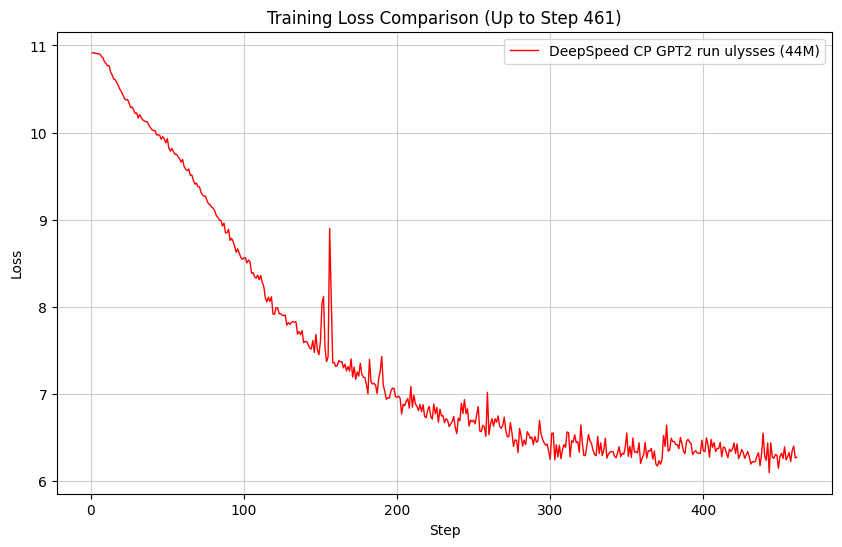

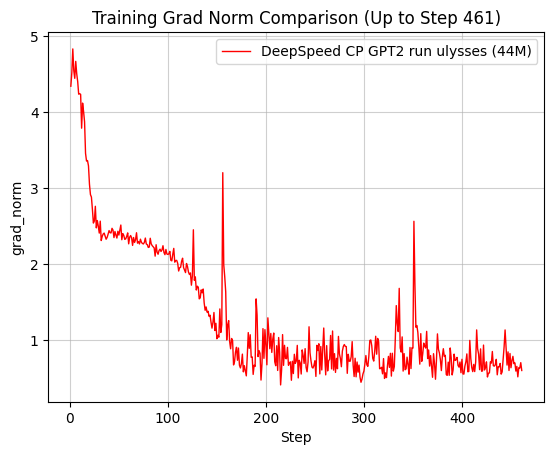

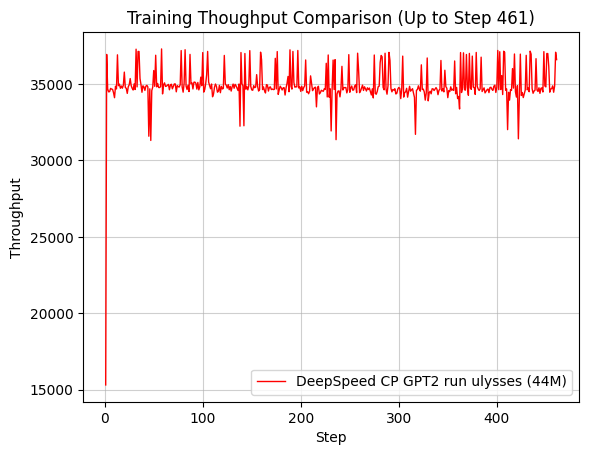

Max. Throughput DeepSpeed CP GPT2 run ulysses (44M): 37306.5
Avg. Throughput DeepSpeed CP GPT2 run ulysses (44M): 34913.639045553144
Min Train Loss DeepSpeed CP GPT2 run ulysses (44M): 6.094388
Min Val Loss DeepSpeed CP GPT2 run ulysses (44M): nan
Avg. Time DeepSpeed CP GPT2 run ulysses (44M): 1881.3791409978307
Avg. Data Time DeepSpeed CP GPT2 run ulysses (44M): 26.385980477223423
Avg. Forward Time DeepSpeed CP GPT2 run ulysses (44M): 501.21097830802603
Avg. Loss Time DeepSpeed CP GPT2 run ulysses (44M): 0.0
Avg. Backward Time DeepSpeed CP GPT2 run ulysses (44M): 1311.803433839479


In [40]:

import pandas as pd
import matplotlib.pyplot as plt

# plt.style.use('')

# Load datasets
# df_old = pd.read_csv('/home/blu-bridge25/CP/CP_GPT2_Training_logs/CP_Training_log2.csv')
df_new = pd.read_csv('/home/blu-bridge25/LlamaFactory/outputs/gpt2_44m_pt_fsdp2_ulysses/training_log4.csv')
# df_3rd = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/CP_Training_logs/CP_Training_log162.csv')

if not df_new.empty:
    # # df_old.columns = df_old.columns.str.strip()
    df_new.columns = df_new.columns.str.strip()
    # df_3rd.columns = df_3rd.columns.str.strip()

# LlamaFactory logs steps 1-indexed (v1 increments global_step before logging);
# the CP framework logs 0-indexed. Shift df_old to 0-indexed so both align.
# # df_old['step'] = df_old['step'] + 1


# 1. Get the current progress (max step of the new run)
current_max_step = df_new['step'].max()

# 2 Filter the old run to match the current progress
# # # df_old_truncated = df_old[df_old['step'] <= current_max_step]
# # # df_3rd_truncated = df_3rd[df_3rd['step'] <= current_max_step]

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['loss'], label='DeepSpeed CP GPT2 run ulysses (44M)', linewidth=1, color = 'red')
# # plt.plot(df_old_truncated['step'], df_old_truncated['loss'], label='Our Ulysses CP run (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['loss'], label='DeepSpeed CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title(f'Training Loss Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='DeepSpeed CP GPT2 run ulysses (44M)', linewidth=1, color = 'red')
# # plt.plot(df_old_truncated['step'], df_old_truncated['grad_norm'], label='Our Ulysses CP run (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['grad_norm'], label='DeepSpeed CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='DeepSpeed CP GPT2 run ulysses (44M)', linewidth=1, color = 'red')
# # plt.plot(df_old_truncated['step'], df_old_truncated['tok_per_sec'], label='Our Ulysses CP run (44M)',linewidth=1, linestyle = "-", color = "blue", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['tok_per_sec'], label='DeepSpeed CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.8)

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput DeepSpeed CP GPT2 run ulysses (44M):",df_new['tok_per_sec'].max())
print("Avg. Throughput DeepSpeed CP GPT2 run ulysses (44M):",df_new['tok_per_sec'].mean())
print("Min Train Loss DeepSpeed CP GPT2 run ulysses (44M):",df_new['loss'][:].min())
print("Min Val Loss DeepSpeed CP GPT2 run ulysses (44M):",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['dt_ms'].mean())
print("Avg. Data Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_data'][:].mean())
print("Avg. Forward Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_loss'][:].mean())
print("Avg. Backward Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_bwd'][:].mean())


# print("\nMax. Throughput Our Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].max())
# print("Avg. Throughput Our Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].mean())
# print("Min Train Loss Our Ulysses CP run (44M):",df_old_truncated['loss'][:].min())
# # print("Min Val Loss Our Ulysses CP run (44M):",df_old_truncated['val_loss'].where(df_old_truncated['val_loss']!=(-1)).min())
# print("Avg. Time Our Ulysses CP run (44M):",df_old_truncated['dt_ms'].mean())
# print("Avg. Data Time Our Ulysses CP run (44M):",df_old_truncated['timer_data'][:].mean())
# print("Avg. Forward Time Our Ulysses CP run (44M):",df_old_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time Our Ulysses CP run (44M):",df_old_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time Our Ulysses CP run (44M):",df_old_truncated['timer_bwd'][:].mean())




# print("\nMax. Throughput DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['tok_per_sec'].max())
# print("Avg. Throughput DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['tok_per_sec'].mean())
# print("Min Train Loss DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['loss'][:].min())
# # print("Min Val Loss DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['val_loss'].where(df_3rd_truncated['val_loss']!=(-1)).min())
# print("Avg. Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['dt_ms'].mean())
# print("Avg. Data Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_data'][:].mean())
# print("Avg. Forward Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_lm_head'][:].mean())

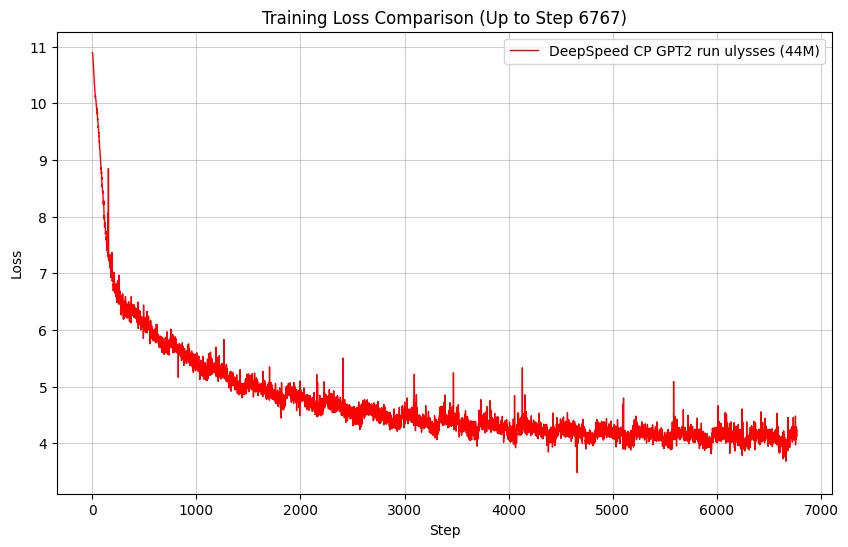

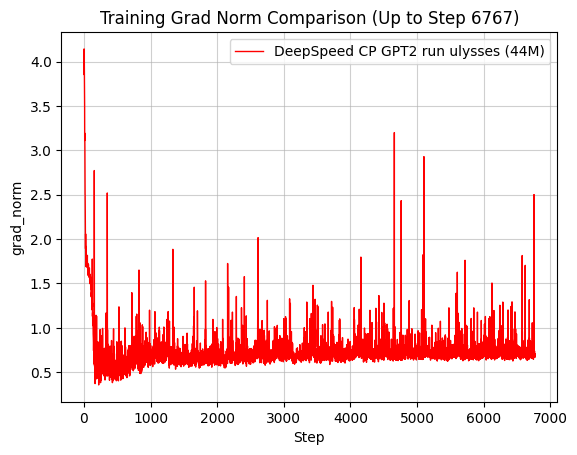

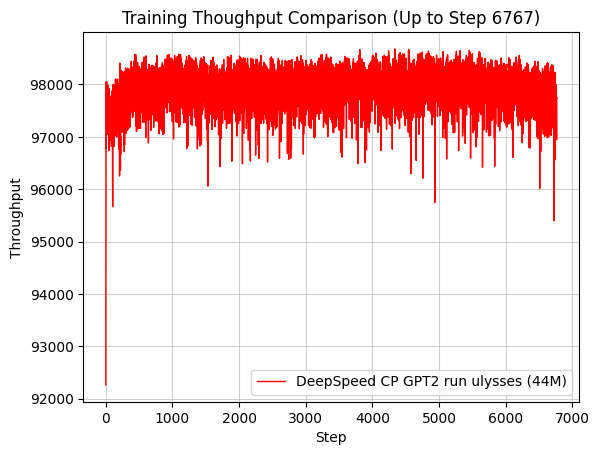

Max. Throughput DeepSpeed CP GPT2 run ulysses (44M): 98678.6
Avg. Throughput DeepSpeed CP GPT2 run ulysses (44M): 98052.75220153664
Min Train Loss DeepSpeed CP GPT2 run ulysses (44M): 3.48231
Min Val Loss DeepSpeed CP GPT2 run ulysses (44M): 4.042305
Avg. Time DeepSpeed CP GPT2 run ulysses (44M): 668.3844246453901
Avg. Data Time DeepSpeed CP GPT2 run ulysses (44M): 2.6248560874704494
Avg. Forward Time DeepSpeed CP GPT2 run ulysses (44M): 138.34978442671394
Avg. Loss Time DeepSpeed CP GPT2 run ulysses (44M): 110.56726979905436
Avg. Backward Time DeepSpeed CP GPT2 run ulysses (44M): 398.1321558806146


In [41]:

import pandas as pd
import matplotlib.pyplot as plt

# plt.style.use('')

# Load datasets
# df_old = pd.read_csv('/home/blu-bridge25/CP/CP_GPT2_Training_logs/CP_Training_log2.csv')
df_new = pd.read_csv('/home/blu-bridge25/LlamaFactory/ds_ulysses/ds_ulysses_run1.csv')
# df_3rd = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/CP_Training_logs/CP_Training_log162.csv')

if not df_new.empty:
    # # df_old.columns = df_old.columns.str.strip()
    df_new.columns = df_new.columns.str.strip()
    # df_3rd.columns = df_3rd.columns.str.strip()

# LlamaFactory logs steps 1-indexed (v1 increments global_step before logging);
# the CP framework logs 0-indexed. Shift df_old to 0-indexed so both align.
# # df_old['step'] = df_old['step'] + 1


# 1. Get the current progress (max step of the new run)
current_max_step = df_new['step'].max()

# 2 Filter the old run to match the current progress
# # # df_old_truncated = df_old[df_old['step'] <= current_max_step]
# # # df_3rd_truncated = df_3rd[df_3rd['step'] <= current_max_step]

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['loss'], label='DeepSpeed CP GPT2 run ulysses (44M)', linewidth=1, color = 'red')
# # plt.plot(df_old_truncated['step'], df_old_truncated['loss'], label='Our Ulysses CP run (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['loss'], label='DeepSpeed CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title(f'Training Loss Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='DeepSpeed CP GPT2 run ulysses (44M)', linewidth=1, color = 'red')
# # plt.plot(df_old_truncated['step'], df_old_truncated['grad_norm'], label='Our Ulysses CP run (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['grad_norm'], label='DeepSpeed CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='DeepSpeed CP GPT2 run ulysses (44M)', linewidth=1, color = 'red')
# # plt.plot(df_old_truncated['step'], df_old_truncated['tok_per_sec'], label='Our Ulysses CP run (44M)',linewidth=1, linestyle = "-", color = "blue", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['tok_per_sec'], label='DeepSpeed CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.8)

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput DeepSpeed CP GPT2 run ulysses (44M):",df_new['tok_per_sec'].max())
print("Avg. Throughput DeepSpeed CP GPT2 run ulysses (44M):",df_new['tok_per_sec'].mean())
print("Min Train Loss DeepSpeed CP GPT2 run ulysses (44M):",df_new['loss'][:].min())
print("Min Val Loss DeepSpeed CP GPT2 run ulysses (44M):",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['dt_ms'].mean())
print("Avg. Data Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_data'][:].mean())
print("Avg. Forward Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_loss'][:].mean())
print("Avg. Backward Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_bwd'][:].mean())


# print("\nMax. Throughput Our Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].max())
# print("Avg. Throughput Our Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].mean())
# print("Min Train Loss Our Ulysses CP run (44M):",df_old_truncated['loss'][:].min())
# # print("Min Val Loss Our Ulysses CP run (44M):",df_old_truncated['val_loss'].where(df_old_truncated['val_loss']!=(-1)).min())
# print("Avg. Time Our Ulysses CP run (44M):",df_old_truncated['dt_ms'].mean())
# print("Avg. Data Time Our Ulysses CP run (44M):",df_old_truncated['timer_data'][:].mean())
# print("Avg. Forward Time Our Ulysses CP run (44M):",df_old_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time Our Ulysses CP run (44M):",df_old_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time Our Ulysses CP run (44M):",df_old_truncated['timer_bwd'][:].mean())




# print("\nMax. Throughput DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['tok_per_sec'].max())
# print("Avg. Throughput DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['tok_per_sec'].mean())
# print("Min Train Loss DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['loss'][:].min())
# # print("Min Val Loss DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['val_loss'].where(df_3rd_truncated['val_loss']!=(-1)).min())
# print("Avg. Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['dt_ms'].mean())
# print("Avg. Data Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_data'][:].mean())
# print("Avg. Forward Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_lm_head'][:].mean())

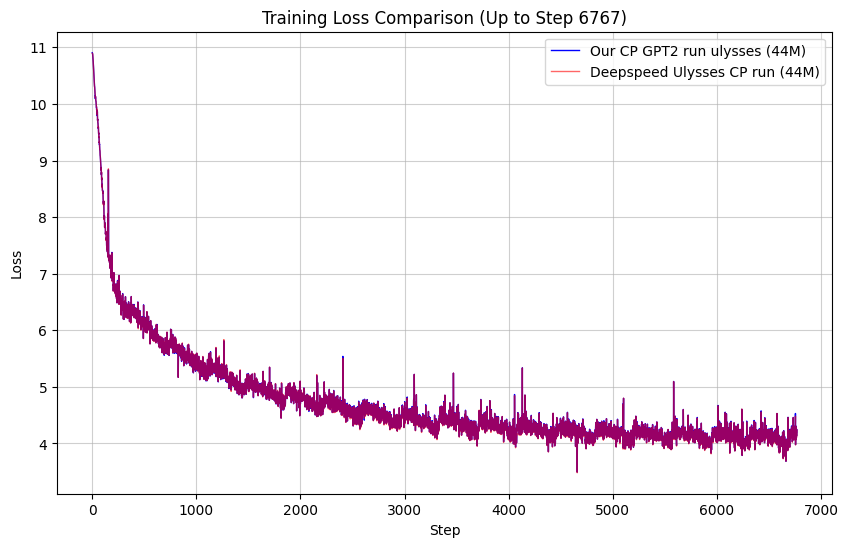

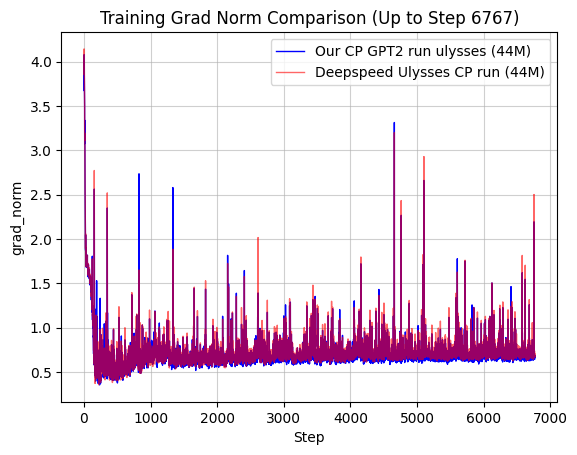

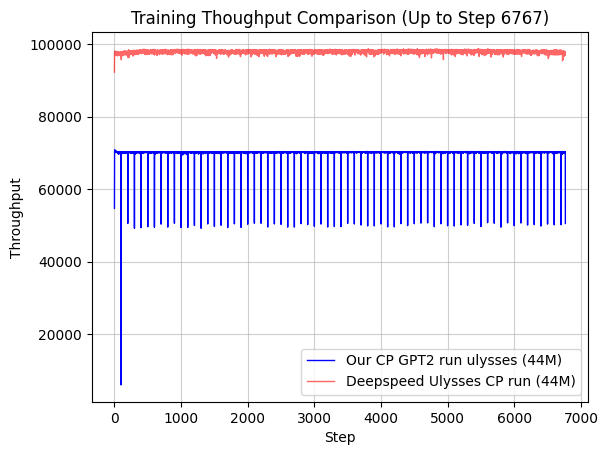

Max. Throughput Our CP GPT2 run ulysses (44M): 70862.16259
Avg. Throughput Our CP GPT2 run ulysses (44M): 69995.15589971069
Min Train Loss Our CP GPT2 run ulysses (44M): 3.493364
Min Val Loss Our CP GPT2 run ulysses (44M): 4.04812
Avg. Time Our CP GPT2 run ulysses (44M): 938.7320811217494
Avg. Data Time Our CP GPT2 run ulysses (44M): 0.546077304964539
Avg. Forward Time Our CP GPT2 run ulysses (44M): 293.63021466046104
Avg. Loss Time Our CP GPT2 run ulysses (44M): 20.400943196217494
Avg. Backward Time Our CP GPT2 run ulysses (44M): 566.3760660994385

Max. Throughput Deepspeed Ulysses CP run (44M): 98678.6
Avg. Throughput Deepspeed Ulysses CP run (44M): 98052.75220153664
Min Train Loss Deepspeed Ulysses CP run (44M): 3.48231
Min Val Loss Deepspeed Ulysses CP run (44M): 4.042305
Avg. Time Deepspeed Ulysses CP run (44M): 668.3844246453901
Avg. Data Time Deepspeed Ulysses CP run (44M): 2.6248560874704494
Avg. Forward Time Deepspeed Ulysses CP run (44M): 138.34978442671394
Avg. Loss Time Dee

In [68]:

import pandas as pd
import matplotlib.pyplot as plt

# plt.style.use('')

# Load datasets
df_new = pd.read_csv('/home/blu-bridge25/CP/CP_GPT2_Training_logs/CP_Training_log3.csv')
df_old = pd.read_csv('/home/blu-bridge25/LlamaFactory/ds_ulysses/ds_ulysses_run1.csv')
# df_3rd = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/CP_Training_logs/CP_Training_log162.csv')

if not df_new.empty:
    df_old.columns = df_old.columns.str.strip()
    df_new.columns = df_new.columns.str.strip()
    # df_3rd.columns = df_3rd.columns.str.strip()

# LlamaFactory logs steps 1-indexed (v1 increments global_step before logging);
# the CP framework logs 0-indexed. Shift df_old to 0-indexed so both align.
# df_old['step'] = df_old['step'] + 1


# 1. Get the current progress (max step of the new run)
current_max_step = df_new['step'].max()

# 2 Filter the old run to match the current progress
df_old_truncated = df_old[df_old['step'] <= current_max_step]
# # # df_3rd_truncated = df_3rd[df_3rd['step'] <= current_max_step]

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['loss'], label='Our CP GPT2 run ulysses (44M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['loss'], label='Deepspeed Ulysses CP run (44M)',linewidth = 1, linestyle = "-", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['loss'], label='Our CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title(f'Training Loss Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='Our CP GPT2 run ulysses (44M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['grad_norm'], label='Deepspeed Ulysses CP run (44M)',linewidth = 1, linestyle = "-", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['grad_norm'], label='Our CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='Our CP GPT2 run ulysses (44M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['tok_per_sec'], label='Deepspeed Ulysses CP run (44M)',linewidth=1, linestyle = "-", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['tok_per_sec'], label='Our CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.8)

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput Our CP GPT2 run ulysses (44M):",df_new['tok_per_sec'].max())
print("Avg. Throughput Our CP GPT2 run ulysses (44M):",df_new['tok_per_sec'].mean())
print("Min Train Loss Our CP GPT2 run ulysses (44M):",df_new['loss'][:].min())
print("Min Val Loss Our CP GPT2 run ulysses (44M):",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time Our CP GPT2 run ulysses (44M):",df_new['dt_ms'].mean())
print("Avg. Data Time Our CP GPT2 run ulysses (44M):",df_new['timer_data'][:].mean())
print("Avg. Forward Time Our CP GPT2 run ulysses (44M):",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time Our CP GPT2 run ulysses (44M):",df_new['timer_loss'][:].mean())
print("Avg. Backward Time Our CP GPT2 run ulysses (44M):",df_new['timer_bwd'][:].mean())


print("\nMax. Throughput Deepspeed Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].max())
print("Avg. Throughput Deepspeed Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].mean())
print("Min Train Loss Deepspeed Ulysses CP run (44M):",df_old_truncated['loss'][:].min())
print("Min Val Loss Deepspeed Ulysses CP run (44M):",df_old_truncated['val_loss'].where(df_old_truncated['val_loss']!=(-1)).min())
print("Avg. Time Deepspeed Ulysses CP run (44M):",df_old_truncated['dt_ms'].mean())
print("Avg. Data Time Deepspeed Ulysses CP run (44M):",df_old_truncated['timer_data'][:].mean())
print("Avg. Forward Time Deepspeed Ulysses CP run (44M):",df_old_truncated['timer_fwd'][:].mean())
print("Avg. Loss Time Deepspeed Ulysses CP run (44M):",df_old_truncated['timer_loss'][:].mean())
print("Avg. Backward Time Deepspeed Ulysses CP run (44M):",df_old_truncated['timer_bwd'][:].mean())




# print("\nMax. Throughput DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['tok_per_sec'].max())
# print("Avg. Throughput DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['tok_per_sec'].mean())
# print("Min Train Loss DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['loss'][:].min())
# # print("Min Val Loss DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['val_loss'].where(df_3rd_truncated['val_loss']!=(-1)).min())
# print("Avg. Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['dt_ms'].mean())
# print("Avg. Data Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_data'][:].mean())
# print("Avg. Forward Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_lm_head'][:].mean())

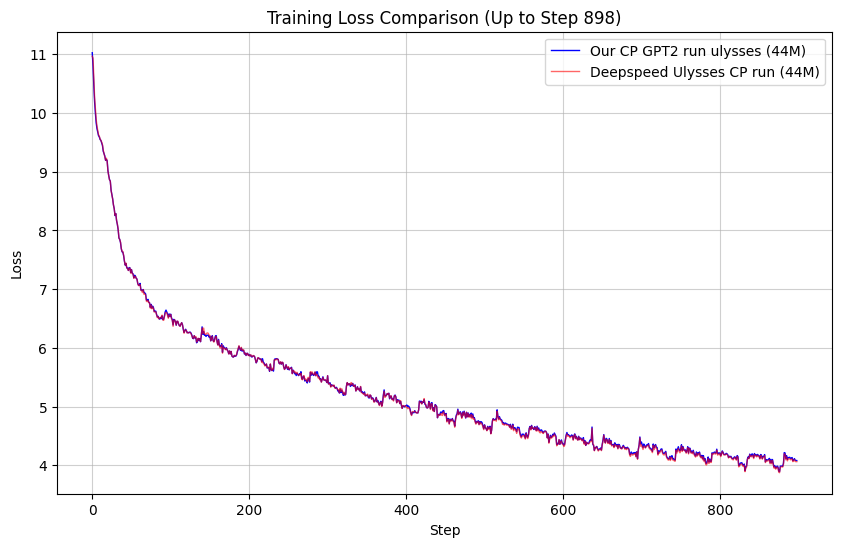

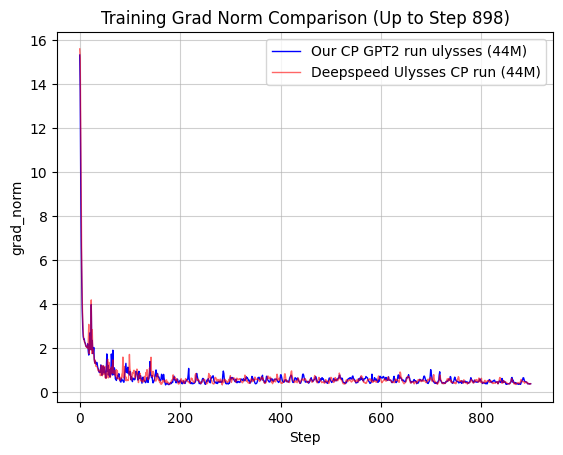

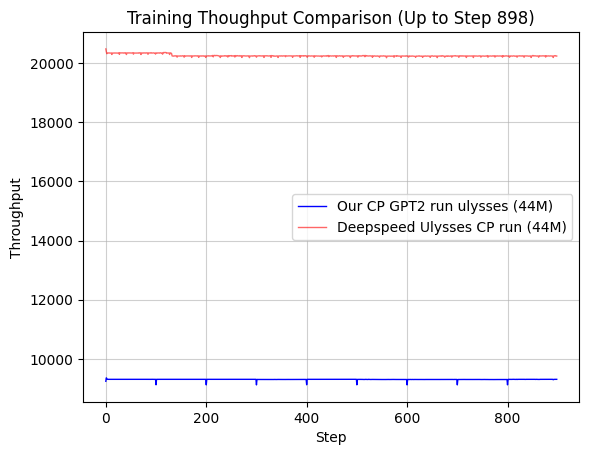

Max. Throughput Our CP GPT2 run ulysses (44M): 9358.295905
Avg. Throughput Our CP GPT2 run ulysses (44M): 9304.980265580643
Min Train Loss Our CP GPT2 run ulysses (44M): 3.891439
Min Val Loss Our CP GPT2 run ulysses (44M): 4.083881
Avg. Time Our CP GPT2 run ulysses (44M): 56345.088692282545
Avg. Data Time Our CP GPT2 run ulysses (44M): 19.525416258064517
Avg. Forward Time Our CP GPT2 run ulysses (44M): 18946.112463591766
Avg. Loss Time Our CP GPT2 run ulysses (44M): 316.1228473793104
Avg. Backward Time Our CP GPT2 run ulysses (44M): 37004.63956368409

Max. Throughput Deepspeed Ulysses CP run (44M): 20473.8
Avg. Throughput Deepspeed Ulysses CP run (44M): 20247.821690767516
Min Train Loss Deepspeed Ulysses CP run (44M): 3.874526
Min Val Loss Deepspeed Ulysses CP run (44M): 4.059129
Avg. Time Deepspeed Ulysses CP run (44M): 25893.64516907675
Avg. Data Time Deepspeed Ulysses CP run (44M): 43.39512013348165
Avg. Forward Time Deepspeed Ulysses CP run (44M): 7116.655731924361
Avg. Loss Time D

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# plt.style.use('')

# Load datasets
df_new = pd.read_csv('/home/blu-bridge25/CP/CP_GPT2_Training_logs/CP_Training_log10.csv')
df_old = pd.read_csv('/home/blu-bridge25/LlamaFactory/ds_ulysses/ds_ulysses_run3.csv')
# df_3rd = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/CP_Training_logs/CP_Training_log162.csv')

if not df_new.empty:
    df_old.columns = df_old.columns.str.strip()
    df_new.columns = df_new.columns.str.strip()
    # df_3rd.columns = df_3rd.columns.str.strip()

# LlamaFactory logs steps 1-indexed (v1 increments global_step before logging);
# the CP framework logs 0-indexed. Shift df_old to 0-indexed so both align.
# df_old['step'] = df_old['step'] + 1


# 1. Get the current progress (max step of the new run)
current_max_step = df_new['step'].max()

# 2 Filter the old run to match the current progress
df_old_truncated = df_old[df_old['step'] <= current_max_step]
# # # df_3rd_truncated = df_3rd[df_3rd['step'] <= current_max_step]

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['loss'], label='Our CP GPT2 run ulysses (44M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['loss'], label='Deepspeed Ulysses CP run (44M)',linewidth = 1, linestyle = "-", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['loss'], label='Our CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title(f'Training Loss Comparison 1 GPU (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='Our CP GPT2 run ulysses (44M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['grad_norm'], label='Deepspeed Ulysses CP run (44M)',linewidth = 1, linestyle = "-", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['grad_norm'], label='Our CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison 1 GPU (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='Our CP GPT2 run ulysses (44M)', linewidth=1, color = 'blue')
plt.plot(df_old_truncated['step'], df_old_truncated['tok_per_sec'], label='Deepspeed Ulysses CP run (44M)',linewidth=1, linestyle = "-", color = "red", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['tok_per_sec'], label='Our CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.8)

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison 1 GPU (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput Our CP GPT2 run ulysses (44M):",df_new['tok_per_sec'].max())
print("Avg. Throughput Our CP GPT2 run ulysses (44M):",df_new['tok_per_sec'].mean())
print("Min Train Loss Our CP GPT2 run ulysses (44M):",df_new['loss'][:].min())
print("Min Val Loss Our CP GPT2 run ulysses (44M):",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time Our CP GPT2 run ulysses (44M):",df_new['dt_ms'].mean())
print("Avg. Data Time Our CP GPT2 run ulysses (44M):",df_new['timer_data'][:].mean())
print("Avg. Forward Time Our CP GPT2 run ulysses (44M):",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time Our CP GPT2 run ulysses (44M):",df_new['timer_loss'][:].mean())
print("Avg. Backward Time Our CP GPT2 run ulysses (44M):",df_new['timer_bwd'][:].mean())


print("\nMax. Throughput Deepspeed Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].max())
print("Avg. Throughput Deepspeed Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].mean())
print("Min Train Loss Deepspeed Ulysses CP run (44M):",df_old_truncated['loss'][:].min())
print("Min Val Loss Deepspeed Ulysses CP run (44M):",df_old_truncated['val_loss'].where(df_old_truncated['val_loss']!=(-1)).min())
print("Avg. Time Deepspeed Ulysses CP run (44M):",df_old_truncated['dt_ms'].mean())
print("Avg. Data Time Deepspeed Ulysses CP run (44M):",df_old_truncated['timer_data'][:].mean())
print("Avg. Forward Time Deepspeed Ulysses CP run (44M):",df_old_truncated['timer_fwd'][:].mean())
print("Avg. Loss Time Deepspeed Ulysses CP run (44M):",df_old_truncated['timer_loss'][:].mean())
print("Avg. Backward Time Deepspeed Ulysses CP run (44M):",df_old_truncated['timer_bwd'][:].mean())




# print("\nMax. Throughput DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['tok_per_sec'].max())
# print("Avg. Throughput DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['tok_per_sec'].mean())
# print("Min Train Loss DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['loss'][:].min())
# # print("Min Val Loss DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['val_loss'].where(df_3rd_truncated['val_loss']!=(-1)).min())
# print("Avg. Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['dt_ms'].mean())
# print("Avg. Data Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_data'][:].mean())
# print("Avg. Forward Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_lm_head'][:].mean())

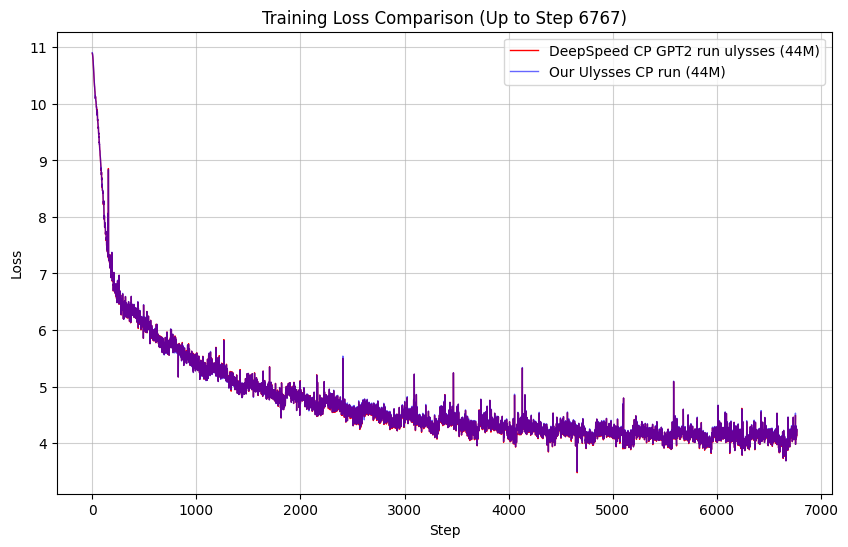

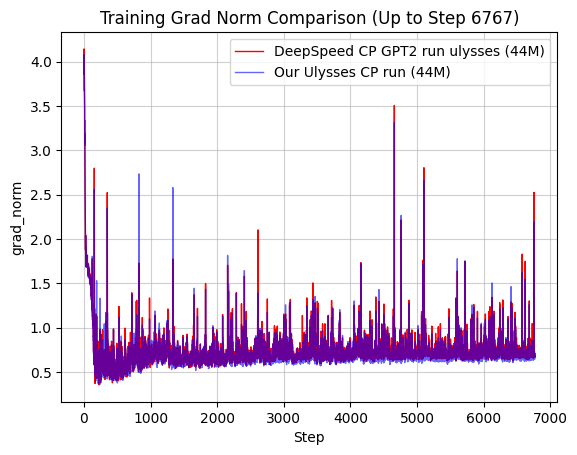

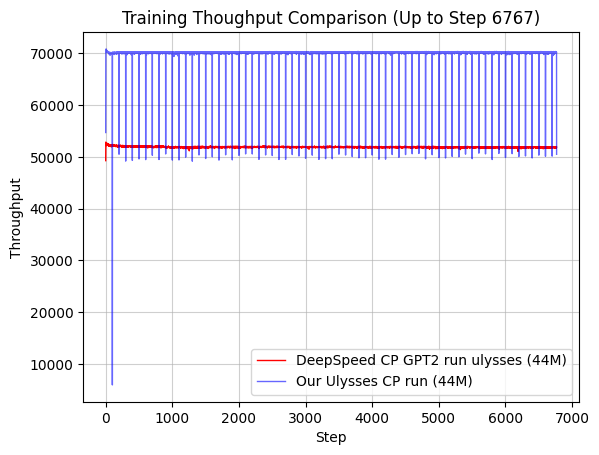

Max. Throughput DeepSpeed CP GPT2 run ulysses (44M): 52866.9
Avg. Throughput DeepSpeed CP GPT2 run ulysses (44M): 51911.512618203305
Min Train Loss DeepSpeed CP GPT2 run ulysses (44M): 3.47537
Min Val Loss DeepSpeed CP GPT2 run ulysses (44M): 4.038041
Avg. Time DeepSpeed CP GPT2 run ulysses (44M): 1262.4624930555558
Avg. Data Time DeepSpeed CP GPT2 run ulysses (44M): 3.5517952127659576
Avg. Forward Time DeepSpeed CP GPT2 run ulysses (44M): 359.09413815011817
Avg. Loss Time DeepSpeed CP GPT2 run ulysses (44M): 79.06856678486997
Avg. Backward Time DeepSpeed CP GPT2 run ulysses (44M): 804.7509945330969

Max. Throughput Our Ulysses CP run (44M): 70862.16259
Avg. Throughput Our Ulysses CP run (44M): 69995.15589971069
Min Train Loss Our Ulysses CP run (44M): 3.493364
Min Val Loss Our Ulysses CP run (44M): 4.04812
Avg. Time Our Ulysses CP run (44M): 938.7320811217494
Avg. Data Time Our Ulysses CP run (44M): 0.546077304964539
Avg. Forward Time Our Ulysses CP run (44M): 293.63021466046104
Avg. 

In [79]:

import pandas as pd
import matplotlib.pyplot as plt

# plt.style.use('')

# Load datasets
df_old = pd.read_csv('/home/blu-bridge25/CP/CP_GPT2_Training_logs/CP_Training_log3.csv')
df_new = pd.read_csv('/home/blu-bridge25/LlamaFactory/ds_ulysses/training_log.csv')
# df_3rd = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/CP_Training_logs/CP_Training_log162.csv')

if not df_new.empty:
    df_old.columns = df_old.columns.str.strip()
    df_new.columns = df_new.columns.str.strip()
    # df_3rd.columns = df_3rd.columns.str.strip()

# LlamaFactory logs steps 1-indexed (v1 increments global_step before logging);
# the CP framework logs 0-indexed. Shift df_old to 0-indexed so both align.
# df_old['step'] = df_old['step'] + 1


# 1. Get the current progress (max step of the new run)
current_max_step = df_new['step'].max()

# 2 Filter the old run to match the current progress
df_old_truncated = df_old[df_old['step'] <= current_max_step]
# # # df_3rd_truncated = df_3rd[df_3rd['step'] <= current_max_step]

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['loss'], label='DeepSpeed CP GPT2 run ulysses (44M)', linewidth=1, color = 'red')
plt.plot(df_old_truncated['step'], df_old_truncated['loss'], label='Our Ulysses CP run (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['loss'], label='DeepSpeed CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title(f'Training Loss Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='DeepSpeed CP GPT2 run ulysses (44M)', linewidth=1, color = 'red')
plt.plot(df_old_truncated['step'], df_old_truncated['grad_norm'], label='Our Ulysses CP run (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['grad_norm'], label='DeepSpeed CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='DeepSpeed CP GPT2 run ulysses (44M)', linewidth=1, color = 'red')
plt.plot(df_old_truncated['step'], df_old_truncated['tok_per_sec'], label='Our Ulysses CP run (44M)',linewidth=1, linestyle = "-", color = "blue", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['tok_per_sec'], label='DeepSpeed CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.8)

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput DeepSpeed CP GPT2 run ulysses (44M):",df_new['tok_per_sec'].max())
print("Avg. Throughput DeepSpeed CP GPT2 run ulysses (44M):",df_new['tok_per_sec'].mean())
print("Min Train Loss DeepSpeed CP GPT2 run ulysses (44M):",df_new['loss'][:].min())
print("Min Val Loss DeepSpeed CP GPT2 run ulysses (44M):",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['dt_ms'].mean())
print("Avg. Data Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_data'][:].mean())
print("Avg. Forward Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_loss'][:].mean())
print("Avg. Backward Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_bwd'][:].mean())


print("\nMax. Throughput Our Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].max())
print("Avg. Throughput Our Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].mean())
print("Min Train Loss Our Ulysses CP run (44M):",df_old_truncated['loss'][:].min())
print("Min Val Loss Our Ulysses CP run (44M):",df_old_truncated['val_loss'].where(df_old_truncated['val_loss']!=(-1)).min())
print("Avg. Time Our Ulysses CP run (44M):",df_old_truncated['dt_ms'].mean())
print("Avg. Data Time Our Ulysses CP run (44M):",df_old_truncated['timer_data'][:].mean())
print("Avg. Forward Time Our Ulysses CP run (44M):",df_old_truncated['timer_fwd'][:].mean())
print("Avg. Loss Time Our Ulysses CP run (44M):",df_old_truncated['timer_loss'][:].mean())
print("Avg. Backward Time Our Ulysses CP run (44M):",df_old_truncated['timer_bwd'][:].mean())


# ===== MFU (Model FLOPs Utilization) =====
# Both runs = GPT-2 MODEL_44M (gpt2_cp_test.cpp): n_layer=3, n_head=6, head_dim=64, seq=1024.
# tok_per_sec in the CSV is the AGGREGATE (system) throughput = global_batch / dt.
N_PARAMS = 44_351_488                       # total params, untied (use ~24.9M if --tie_weights)
N_LAYER, N_HEAD, HEAD_DIM, SEQ = 3, 6, 64, 1024
N_GPUS = 2
PEAK_TFLOPS_PER_GPU = 12.74                 # RTX 3060 FP32 CUDA cores (these runs are fp32)
peak_flops = PEAK_TFLOPS_PER_GPU * 1e12 * N_GPUS

# nanoGPT estimate: fwd+bwd matmul FLOPs (6*N) + attention FLOPs per token
flops_per_token = 6 * N_PARAMS + 12 * N_LAYER * N_HEAD * HEAD_DIM * SEQ

def mfu_pct(df):
    return 100.0 * flops_per_token * df['tok_per_sec'].mean() / peak_flops

print("\nMFU DeepSpeed CP GPT2 run ulysses (44M): %.2f %%" % mfu_pct(df_new))
print("MFU Our Ulysses CP run (44M):            %.2f %%" % mfu_pct(df_old_truncated))




# print("\nMax. Throughput DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['tok_per_sec'].max())
# print("Avg. Throughput DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['tok_per_sec'].mean())
# print("Min Train Loss DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['loss'][:].min())
# # print("Min Val Loss DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['val_loss'].where(df_3rd_truncated['val_loss']!=(-1)).min())
# print("Avg. Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['dt_ms'].mean())
# print("Avg. Data Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_data'][:].mean())
# print("Avg. Forward Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_lm_head'][:].mean())

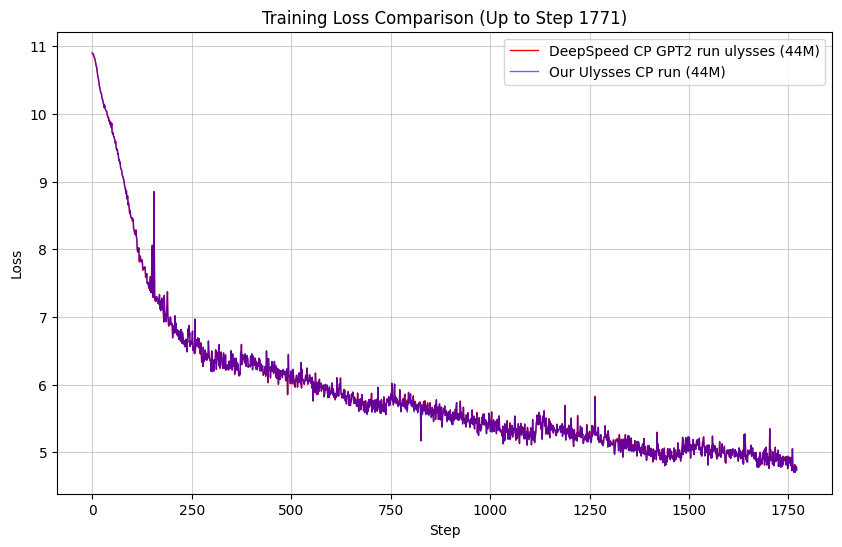

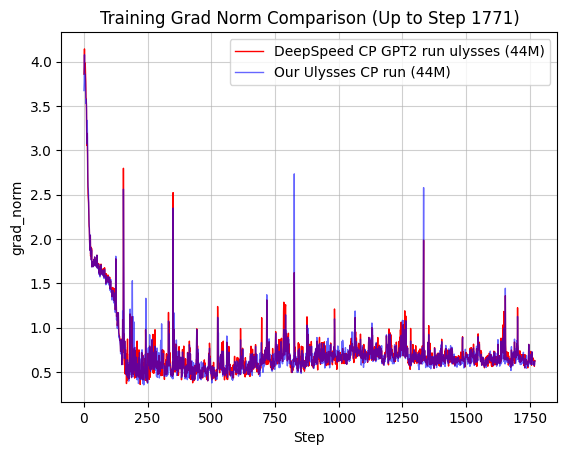

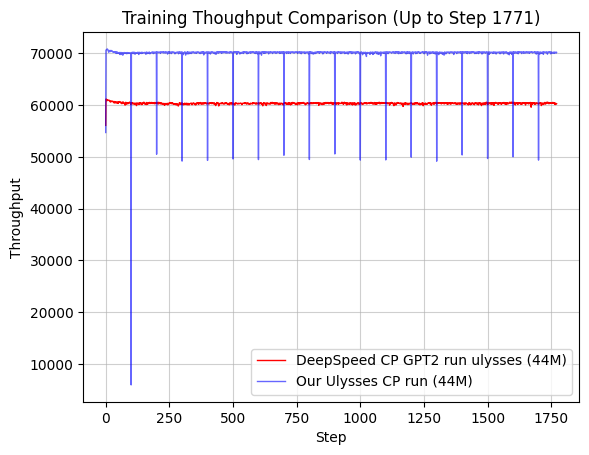

Max. Throughput DeepSpeed CP GPT2 run ulysses (44M): 61180.6
Avg. Throughput DeepSpeed CP GPT2 run ulysses (44M): 60349.15321670429
Min Train Loss DeepSpeed CP GPT2 run ulysses (44M): 4.707348
Min Val Loss DeepSpeed CP GPT2 run ulysses (44M): 4.921005
Avg. Time DeepSpeed CP GPT2 run ulysses (44M): 1085.9559362302482
Avg. Data Time DeepSpeed CP GPT2 run ulysses (44M): 3.264121331828442
Avg. Forward Time DeepSpeed CP GPT2 run ulysses (44M): 281.501230248307
Avg. Loss Time DeepSpeed CP GPT2 run ulysses (44M): 79.1009841986456
Avg. Backward Time DeepSpeed CP GPT2 run ulysses (44M): 706.1142533860045

Max. Throughput Our Ulysses CP run (44M): 70862.16259
Avg. Throughput Our Ulysses CP run (44M): 69949.531822921
Min Train Loss Our Ulysses CP run (44M): 4.698831
Min Val Loss Our Ulysses CP run (44M): 4.911303
Avg. Time Our Ulysses CP run (44M): 943.1439794469526
Avg. Data Time Our Ulysses CP run (44M): 0.5765879548532731
Avg. Forward Time Our Ulysses CP run (44M): 293.7155352861174
Avg. Loss 

In [83]:

import pandas as pd
import matplotlib.pyplot as plt

# plt.style.use('')

# Load datasets
df_old = pd.read_csv('/home/blu-bridge25/CP/CP_GPT2_Training_logs/CP_Training_log3.csv')
df_new = pd.read_csv('/home/blu-bridge25/LlamaFactory/ds_ulysses/training_log.csv')
# df_3rd = pd.read_csv('/home/blu-bridge25/TP/OldPush/TensorParallelismBeta/DTensor/CP_Training_logs/CP_Training_log162.csv')

if not df_new.empty:
    df_old.columns = df_old.columns.str.strip()
    df_new.columns = df_new.columns.str.strip()
    # df_3rd.columns = df_3rd.columns.str.strip()

# LlamaFactory logs steps 1-indexed (v1 increments global_step before logging);
# the CP framework logs 0-indexed. Shift df_old to 0-indexed so both align.
# df_old['step'] = df_old['step'] + 1


# 1. Get the current progress (max step of the new run)
current_max_step = df_new['step'].max()

# 2 Filter the old run to match the current progress
df_old_truncated = df_old[df_old['step'] <= current_max_step]
# # # df_3rd_truncated = df_3rd[df_3rd['step'] <= current_max_step]

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(df_new['step'], df_new['loss'], label='DeepSpeed CP GPT2 run ulysses (44M)', linewidth=1, color = 'red')
plt.plot(df_old_truncated['step'], df_old_truncated['loss'], label='Our Ulysses CP run (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['loss'], label='DeepSpeed CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title(f'Training Loss Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)


plt.savefig('comparison_curve.png')
plt.show()

plt.plot(df_new['step'], df_new['grad_norm'], label='DeepSpeed CP GPT2 run ulysses (44M)', linewidth=1, color = 'red')
plt.plot(df_old_truncated['step'], df_old_truncated['grad_norm'], label='Our Ulysses CP run (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['grad_norm'], label='DeepSpeed CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.6)


plt.xlabel('Step')
plt.ylabel('grad_norm')
plt.title(f'Training Grad Norm Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)

plt.show()

plt.plot(df_new['step'], df_new['tok_per_sec'], label='DeepSpeed CP GPT2 run ulysses (44M)', linewidth=1, color = 'red')
plt.plot(df_old_truncated['step'], df_old_truncated['tok_per_sec'], label='Our Ulysses CP run (44M)',linewidth=1, linestyle = "-", color = "blue", alpha=0.6)
# # plt.plot(df_3rd_truncated['step'], df_3rd_truncated['tok_per_sec'], label='DeepSpeed CP GPT2 run before (44M)',linewidth = 1, linestyle = "-", color = "blue", alpha=0.8)

plt.xlabel('Step')
plt.ylabel('Throughput')
plt.title(f'Training Thoughput Comparison (Up to Step {current_max_step})')
plt.legend()
plt.grid(True, linestyle='-', alpha=0.6)
plt.savefig('comparison_curve.png')
plt.show()

print("Max. Throughput DeepSpeed CP GPT2 run ulysses (44M):",df_new['tok_per_sec'].max())
print("Avg. Throughput DeepSpeed CP GPT2 run ulysses (44M):",df_new['tok_per_sec'].mean())
print("Min Train Loss DeepSpeed CP GPT2 run ulysses (44M):",df_new['loss'][:].min())
print("Min Val Loss DeepSpeed CP GPT2 run ulysses (44M):",df_new['val_loss'].where(df_new['val_loss']!=(-1)).min())
print("Avg. Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['dt_ms'].mean())
print("Avg. Data Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_data'][:].mean())
print("Avg. Forward Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_fwd'][:].mean())
print("Avg. Loss Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_loss'][:].mean())
print("Avg. Backward Time DeepSpeed CP GPT2 run ulysses (44M):",df_new['timer_bwd'][:].mean())


print("\nMax. Throughput Our Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].max())
print("Avg. Throughput Our Ulysses CP run (44M):",df_old_truncated['tok_per_sec'].mean())
print("Min Train Loss Our Ulysses CP run (44M):",df_old_truncated['loss'][:].min())
print("Min Val Loss Our Ulysses CP run (44M):",df_old_truncated['val_loss'].where(df_old_truncated['val_loss']!=(-1)).min())
print("Avg. Time Our Ulysses CP run (44M):",df_old_truncated['dt_ms'].mean())
print("Avg. Data Time Our Ulysses CP run (44M):",df_old_truncated['timer_data'][:].mean())
print("Avg. Forward Time Our Ulysses CP run (44M):",df_old_truncated['timer_fwd'][:].mean())
print("Avg. Loss Time Our Ulysses CP run (44M):",df_old_truncated['timer_loss'][:].mean())
print("Avg. Backward Time Our Ulysses CP run (44M):",df_old_truncated['timer_bwd'][:].mean())


# ===== MFU (Model FLOPs Utilization) =====
# Both runs = GPT-2 MODEL_44M (gpt2_cp_test.cpp): n_layer=3, n_head=6, head_dim=64, seq=1024.
# tok_per_sec in the CSV is the AGGREGATE (system) throughput = global_batch / dt.
N_PARAMS = 44_351_488                       # total params, untied (use ~24.9M if --tie_weights)
N_LAYER, N_HEAD, HEAD_DIM, SEQ = 3, 6, 64, 1024
N_GPUS = 2
PEAK_TFLOPS_PER_GPU = 25.5                  # RTX 3060 TF32 tensor cores (~2x fp32); both runs use TF32 matmul
peak_flops = PEAK_TFLOPS_PER_GPU * 1e12 * N_GPUS

# nanoGPT estimate: fwd+bwd matmul FLOPs (6*N) + attention FLOPs per token
flops_per_token = 6 * N_PARAMS + 12 * N_LAYER * N_HEAD * HEAD_DIM * SEQ

def mfu_pct(df):
    return 100.0 * flops_per_token * df['tok_per_sec'].mean() / peak_flops

print("\nMFU DeepSpeed CP GPT2 run ulysses (44M): %.2f %%" % mfu_pct(df_new))
print("MFU Our Ulysses CP run (44M):            %.2f %%" % mfu_pct(df_old_truncated))




# print("\nMax. Throughput DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['tok_per_sec'].max())
# print("Avg. Throughput DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['tok_per_sec'].mean())
# print("Min Train Loss DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['loss'][:].min())
# # print("Min Val Loss DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['val_loss'].where(df_3rd_truncated['val_loss']!=(-1)).min())
# print("Avg. Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['dt_ms'].mean())
# print("Avg. Data Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_data'][:].mean())
# print("Avg. Forward Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_fwd'][:].mean())
# print("Avg. Loss Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_loss'][:].mean())
# print("Avg. Backward Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_bwd'][:].mean())
# print("Avg. Attention Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_attn_cp'][:].mean())
# print("Avg. clip_grad Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_clip'][:].mean())
# print("Avg. Optimizer Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_optim'][:].mean())
# print("Avg. Tok_Emb Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_tok_emb'][:].mean())
# print("Avg. Pos_Emb Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_pos_emb'].mean())
# print("Avg. Mlp Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_mlp'][:].mean())
# print("Avg. Ln_f Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_ln_f'][:].mean())
# print("Avg. LM Head Time DeepSpeed CP GPT2 run before (44M):",df_3rd_truncated['timer_lm_head'][:].mean())